In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline








In [2]:
df=pd.read_csv('churn.csv')

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape


(7043, 21)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [7]:
df.drop(['customerID'],axis=1,inplace=True)

In [8]:
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [9]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

In [10]:
categorical_cols=df.select_dtypes(include=['object']).columns
categorical_cols

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn'],
      dtype='object')

In [11]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')

In [12]:
le_churn=LabelEncoder()
df['Churn']=le_churn.fit_transform(df['Churn'])

In [13]:
binary_cols=[col for col in df.select_dtypes(include='object').columns
            if df[col].nunique()==2

]
binary_cols

['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']

In [14]:
label_encoders={}
for col in binary_cols:
    le=LabelEncoder()
    df[col]=le.fit_transform(df[col])
    label_encoders[col]=le


In [15]:
multi_cat_cols=[col for col in df.select_dtypes(include='object').columns 
     if df[col].nunique()>2
 ]
multi_cat_cols

['MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaymentMethod']

In [18]:
ohe=OneHotEncoder(
    drop='first',
    sparse_output=False,
    handle_unknown='ignore'
    
)
ohe_array = ohe.fit_transform(df[multi_cat_cols])

ohe_df = pd.DataFrame(
    ohe_array,
    columns=ohe.get_feature_names_out(multi_cat_cols),
    index=df.index
)

df = pd.concat([df.drop(columns=multi_cat_cols), ohe_df], axis=1)


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7043 non-null   int64  
 1   SeniorCitizen                          7043 non-null   int64  
 2   Partner                                7043 non-null   int64  
 3   Dependents                             7043 non-null   int64  
 4   tenure                                 7043 non-null   int64  
 5   PhoneService                           7043 non-null   int64  
 6   PaperlessBilling                       7043 non-null   int64  
 7   MonthlyCharges                         7043 non-null   float64
 8   TotalCharges                           7032 non-null   float64
 9   Churn                                  7043 non-null   int64  
 10  MultipleLines_No phone service         7043 non-null   float64
 11  Mult

In [20]:
df.isnull().sum()

gender                                    0
SeniorCitizen                             0
Partner                                   0
Dependents                                0
tenure                                    0
PhoneService                              0
PaperlessBilling                          0
MonthlyCharges                            0
TotalCharges                             11
Churn                                     0
MultipleLines_No phone service            0
MultipleLines_Yes                         0
InternetService_Fiber optic               0
InternetService_No                        0
OnlineSecurity_No internet service        0
OnlineSecurity_Yes                        0
OnlineBackup_No internet service          0
OnlineBackup_Yes                          0
DeviceProtection_No internet service      0
DeviceProtection_Yes                      0
TechSupport_No internet service           0
TechSupport_Yes                           0
StreamingTV_No internet service 

In [21]:
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


C:\Users\Harsha vardhan\AppData\Local\Temp\ipykernel_1332\419782261.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


In [23]:
df.isnull().sum()

gender                                   0
SeniorCitizen                            0
Partner                                  0
Dependents                               0
tenure                                   0
PhoneService                             0
PaperlessBilling                         0
MonthlyCharges                           0
TotalCharges                             0
Churn                                    0
MultipleLines_No phone service           0
MultipleLines_Yes                        0
InternetService_Fiber optic              0
InternetService_No                       0
OnlineSecurity_No internet service       0
OnlineSecurity_Yes                       0
OnlineBackup_No internet service         0
OnlineBackup_Yes                         0
DeviceProtection_No internet service     0
DeviceProtection_Yes                     0
TechSupport_No internet service          0
TechSupport_Yes                          0
StreamingTV_No internet service          0
StreamingTV

In [24]:
df.duplicated().sum()

np.int64(22)

In [25]:
df = df.drop_duplicates()


In [26]:
df['Churn'].value_counts()

Churn
0    5164
1    1857
Name: count, dtype: int64

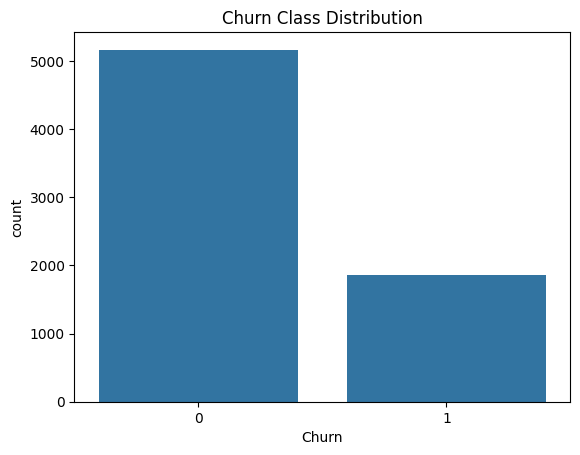

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='Churn', data=df)
plt.title("Churn Class Distribution")
plt.show()


In [28]:
from sklearn.model_selection import train_test_split
x=df.drop('Churn',axis=1)
y=df['Churn']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [29]:
y_train.value_counts()

Churn
0    4131
1    1485
Name: count, dtype: int64

In [31]:
#we will aplly smote on training data for oversampling to mkae it balanced
from imblearn.over_sampling import SMOTE
smote=SMOTE(random_state=42)
x_train_bal,y_train_bal=smote.fit_resample(x_train,y_train)

In [32]:
y_train_bal.value_counts()


Churn
1    4131
0    4131
Name: count, dtype: int64

In [33]:
df.duplicated().sum()

np.int64(0)

In [34]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train_bal)
x_test_scaled=scaler.transform(x_test)

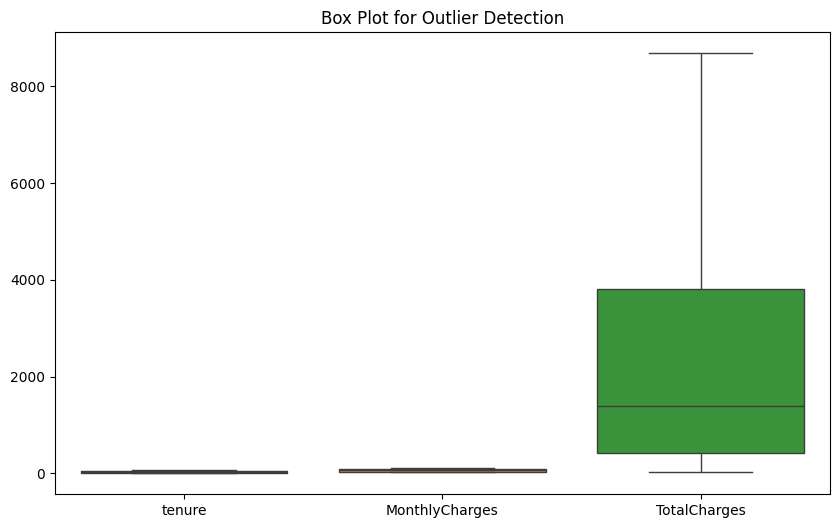

In [35]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[num_cols])
plt.title("Box Plot for Outlier Detection")
plt.show()

In [37]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(x_train_scaled, y_train_bal)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [39]:
y_pred = log_reg.predict(x_test_scaled)


In [40]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


Accuracy: 0.7451957295373666


In [41]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.88      0.76      0.81      1033
           1       0.51      0.71      0.60       372

    accuracy                           0.75      1405
   macro avg       0.70      0.73      0.71      1405
weighted avg       0.78      0.75      0.76      1405



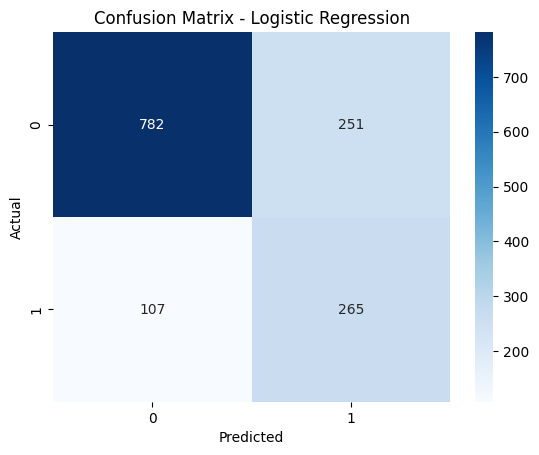

In [42]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()


In [ ]:
#simple correlation with target
corr=df.corr()
corr['Churn'].sort_values(ascending=False)

Churn                                    1.000000
InternetService_Fiber optic              0.308170
PaymentMethod_Electronic check           0.301544
MonthlyCharges                           0.194508
PaperlessBilling                         0.190891
SeniorCitizen                            0.151619
StreamingTV_Yes                          0.065032
StreamingMovies_Yes                      0.063192
MultipleLines_Yes                        0.041958
PhoneService                             0.011323
gender                                  -0.008763
MultipleLines_No phone service          -0.011323
DeviceProtection_Yes                    -0.064944
OnlineBackup_Yes                        -0.081092
PaymentMethod_Mailed check              -0.092562
PaymentMethod_Credit card (automatic)   -0.133666
Partner                                 -0.149135
Dependents                              -0.163459
TechSupport_Yes                         -0.163937
OnlineSecurity_Yes                      -0.170520


Text(0.5, 1.0, 'Correlation with Churn')

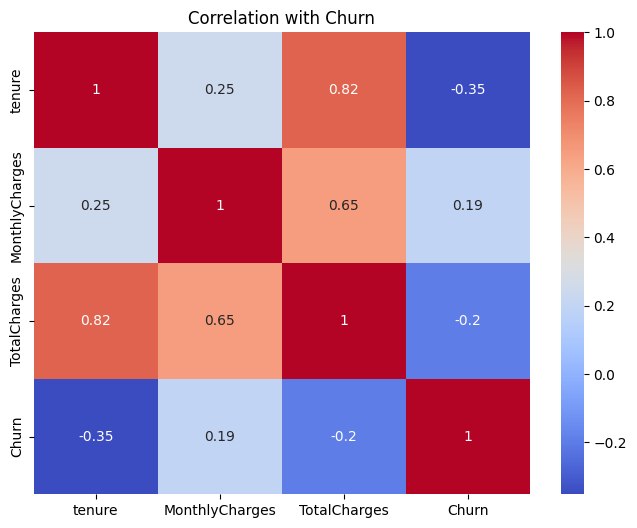

In [45]:
plt.figure(figsize=(8,6))
sns.heatmap(df[['tenure','MonthlyCharges','TotalCharges','Churn']].corr(),
            annot=True, cmap='coolwarm')
plt.title("Correlation with Churn")


In [47]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(x_train_scaled, y_train_bal)

lr_pred = lr.predict(x_test_scaled)


In [50]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(x_train_bal, y_train_bal)

dt_pred = dt.predict(x_test)


In [51]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(x_train_bal, y_train_bal)

rf_pred = rf.predict(x_test)


In [52]:
from sklearn.metrics import classification_report

print("Logistic Regression")
print(classification_report(y_test, lr_pred))

print("Decision Tree")
print(classification_report(y_test, dt_pred))

print("Random Forest")
print(classification_report(y_test, rf_pred))


Logistic Regression
              precision    recall  f1-score   support

           0       0.88      0.76      0.81      1033
           1       0.51      0.71      0.60       372

    accuracy                           0.75      1405
   macro avg       0.70      0.73      0.71      1405
weighted avg       0.78      0.75      0.76      1405

Decision Tree
              precision    recall  f1-score   support

           0       0.83      0.80      0.81      1033
           1       0.49      0.53      0.51       372

    accuracy                           0.73      1405
   macro avg       0.66      0.67      0.66      1405
weighted avg       0.74      0.73      0.73      1405

Random Forest
              precision    recall  f1-score   support

           0       0.82      0.87      0.84      1033
           1       0.56      0.47      0.51       372

    accuracy                           0.76      1405
   macro avg       0.69      0.67      0.68      1405
weighted avg       0.75   

In [54]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

grid.fit(x_train_bal, y_train_bal)


,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [None, 10, ...], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [55]:
grid.best_params_


{'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}

In [57]:
best_model = grid.best_estimator_

y_final_pred = best_model.predict(x_test)

print(classification_report(y_test, y_final_pred))


              precision    recall  f1-score   support

           0       0.87      0.85      0.86      1033
           1       0.60      0.64      0.62       372

    accuracy                           0.79      1405
   macro avg       0.73      0.74      0.74      1405
weighted avg       0.79      0.79      0.79      1405

